In [ ]:
from google.colab import files
uploaded = files.upload()

Saving subscription_payment_history.csv to subscription_payment_history.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv('subscription_payment_history.csv')
print(df.head())
missing_data = df.isnull().sum()
missing_data.head(5)

  CustomerID SubscriptionPlan BillingCycle  IsAutoRenew
0    CUST001            Basic    Quarterly        False
1    CUST002            Basic     Annually         True
2    CUST003            Basic    Quarterly         True
3    CUST004         Standard    Quarterly         True
4    CUST005          Premium     Annually         True


,0
CustomerID,0
SubscriptionPlan,0
BillingCycle,0
IsAutoRenew,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
df_final = df.copy()

df_final['IsAutoRenew'] = df_final['IsAutoRenew'].astype(int)

# One-hot encode 'BillingCycle' and convert to integers
encoded_billing_cycle = pd.get_dummies(df_final['BillingCycle']).astype(int)
label_encoder = LabelEncoder()
df_final = pd.concat([df_final, encoded_billing_cycle], axis=1)
# Applying label encoding to 'SubscriptionPlan'
encoded_subscription_plan = label_encoder.fit_transform(df_final['SubscriptionPlan'])
encoding_map = {'Basic': 0, 'Standard': 1, 'Premium': 2}
df_final['SubscriptionPlan_Encoded'] = df_final['SubscriptionPlan'].map(encoding_map)

columns_to_drop = ['BillingCycle', 'SubscriptionPlan']
df_final = df_final.drop(columns=columns_to_drop, axis=1)

display(df_final.head())

,CustomerID,IsAutoRenew,Annually,Monthly,Quarterly,SubscriptionPlan_Encoded
0,CUST001,0,0,0,1,0
1,CUST002,1,1,0,0,0
2,CUST003,1,0,0,1,0
3,CUST004,1,0,0,1,1
4,CUST005,1,1,0,0,2


Text(0.5, 1.0, 'Distribution of IsAutoRenew')

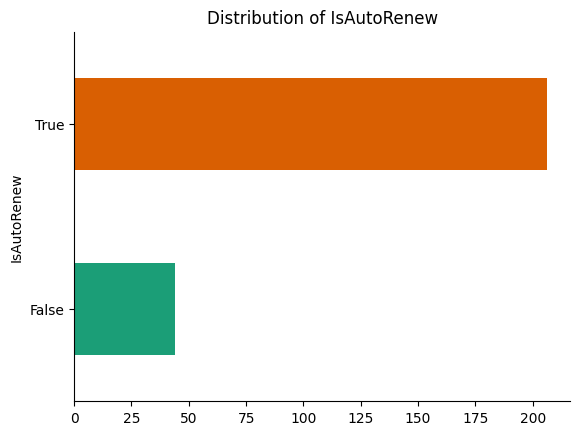

In [ ]:
#Comparing number of users with AutoRenew on and off
df.groupby('IsAutoRenew').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.title('Distribution of IsAutoRenew')

Text(0.5, 1.0, 'Distribution of SubscriptionPlan')

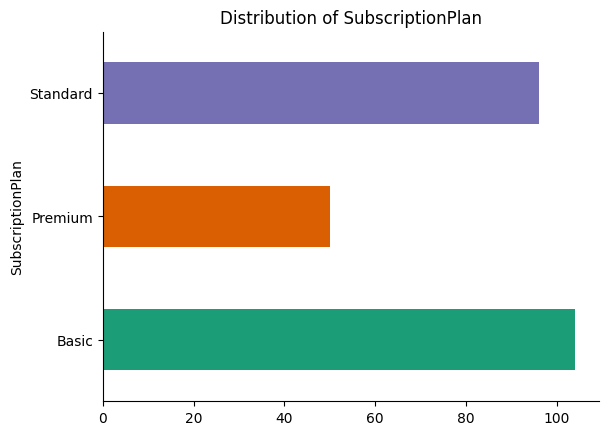

In [ ]:
#Comparing number of users of Standard, Premium and Basic SubscriptionPlan
df.groupby('SubscriptionPlan').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.title('Distribution of SubscriptionPlan')

Text(0.5, 1.0, 'Distribution of BillingCycle')

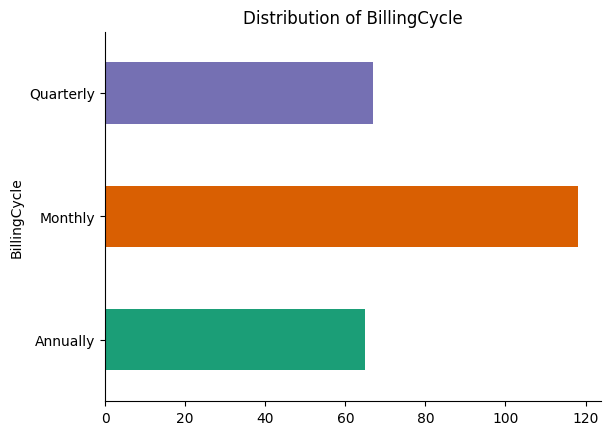

In [ ]:
#Comparing number of users of Quaterly, Monthly and Annually BillingCycle
df.groupby('BillingCycle').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.title('Distribution of BillingCycle')

Text(0.5, 1.0, 'Billing Cycle vs IsAutoRenew')

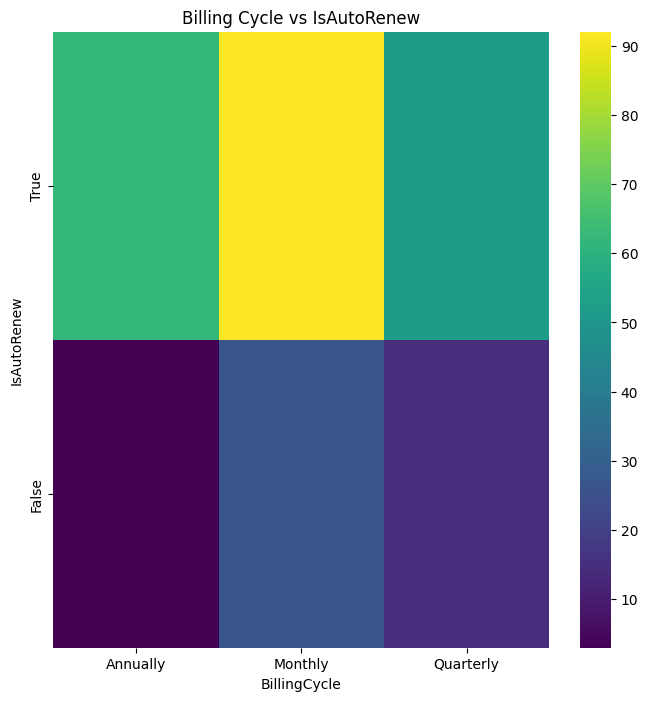

In [ ]:
#BillingCycle vs IsAutoRenew

plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['IsAutoRenew'].value_counts()
    for x_label, grp in df.groupby('BillingCycle')
})
#heat map relating BillingCycle and IsAutoRenew
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('BillingCycle')
_ = plt.ylabel('IsAutoRenew')
plt.title('Billing Cycle vs IsAutoRenew')

Text(0.5, 1.0, 'Subscription Plan vs Billing Cycle')

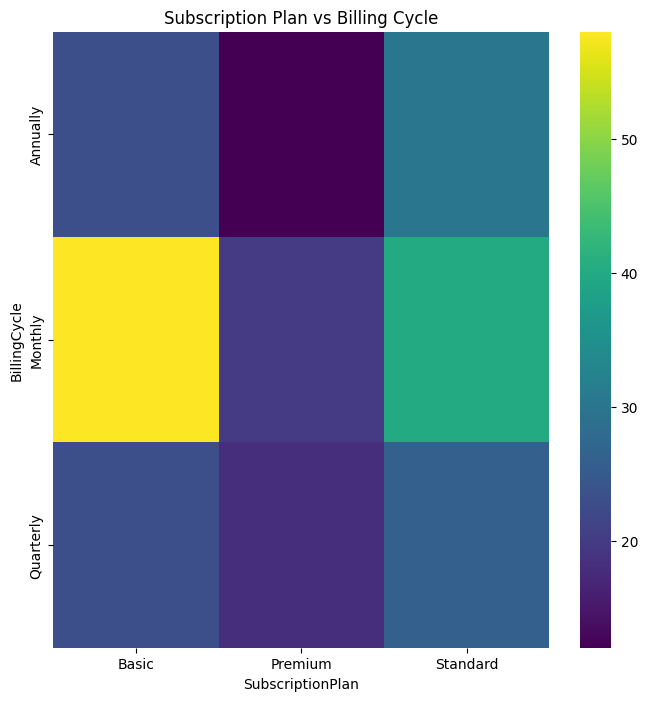

In [ ]:
#SubscriptionPlan vs BillingCycle

plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['BillingCycle'].value_counts()
    for x_label, grp in df.groupby('SubscriptionPlan')
})
#heatmap relating SubscriptionPlan and BillingCycle
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('SubscriptionPlan')
_ = plt.ylabel('BillingCycle')
plt.title('Subscription Plan vs Billing Cycle')

In [ ]:
df_final.to_csv('df_final.csv', index=False)
files.download('df_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>